# Event Study Horario — Conciertos en El Campín / Movistar Arena (2025)

**Pregunta:** ¿Cuánto aumenta la afluencia en las estaciones adyacentes a El Campín durante y después de un concierto?

**Por qué es causal:** Los eventos en El Campín/Movistar Arena son tratamientos discretos con fecha y hora exacta, exógenos a la operación de TransMilenio. La proximidad geográfica de las estaciones al estadio define qué estaciones son "tratadas" vs. "control".

**Método:** Event Study horario — para cada hora $h$ del día, se estima el exceso de demanda en estaciones cercanas en días de evento vs. días equivalentes sin evento (mismo día de semana, sin festivo):

$$\log(\text{total}_{ih}) = \beta_h \cdot \text{evento}_d + \alpha_i + \varepsilon_{ih}$$

Los coeficientes $\beta_h$ se estiman por hora mediante OLS con efectos fijos de estación.

**Estaciones tratadas primarias** (≤500 m del estadio): 7106 Campín-UAN, 7105 Movistar Arena  
**Identificación:** comparación dentro de estación (event vs. no-event), mismo día de semana.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from pathlib import Path
from shapely.geometry import Point

warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Calendario de eventos 2025

In [2]:
# Fuente: prensa (Bogotá.gov.co, El Tiempo, Semana) — construcción manual
CONCIERTOS = {
    '2025-02-21': 'Andrea Bocelli',
    '2025-02-26': 'Shakira (noche 1)',
    '2025-02-27': 'Shakira (noche 2)',
    '2025-03-02': 'Sting',
    '2025-03-07': 'Marco Antonio Solís',
    '2025-05-03': 'Maluma',
    '2025-05-20': 'Rockin 1000',
}

FESTIVAL_VERANO = [
    '2025-08-02', '2025-08-03', '2025-08-04', '2025-08-05',
    '2025-08-06', '2025-08-07', '2025-08-08', '2025-08-09', '2025-08-10',
]

FESTIVOS = {
    '2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18',
    '2025-05-01', '2025-06-02', '2025-06-23', '2025-06-30', '2025-07-20',
    '2025-08-07', '2025-08-18', '2025-10-13', '2025-11-03', '2025-11-17',
    '2025-12-08', '2025-12-25',
}

TODOS_EVENTOS = set(CONCIERTOS.keys()) | set(FESTIVAL_VERANO)

print(f"Conciertos individuales: {len(CONCIERTOS)}")
for fecha, nombre in CONCIERTOS.items():
    dow = pd.to_datetime(fecha).day_name()
    print(f"  {fecha}  {dow[:3]}  {nombre}")
print(f"\nFestival de Verano: {len(FESTIVAL_VERANO)} días (2-10 ago)")

Conciertos individuales: 7
  2025-02-21  Fri  Andrea Bocelli
  2025-02-26  Wed  Shakira (noche 1)
  2025-02-27  Thu  Shakira (noche 2)
  2025-03-02  Sun  Sting
  2025-03-07  Fri  Marco Antonio Solís
  2025-05-03  Sat  Maluma
  2025-05-20  Tue  Rockin 1000

Festival de Verano: 9 días (2-10 ago)


## 2. Clasificación de estaciones por proximidad a El Campín

In [3]:
stations = gpd.read_file(PROJ / 'data/processed/stations_clean.geojson')
stations = stations.rename(columns={'codigo_nodo_estacion': 'codigo_estacion'})
stations_m = stations.to_crs('EPSG:3116')

# El Campín: Cra 24 / Calle 57, Bogotá
campin_gdf = gpd.GeoDataFrame(
    geometry=[Point(-74.0785, 4.6476)], crs='EPSG:4326'
).to_crs('EPSG:3116')
campin_pt = campin_gdf.geometry.iloc[0]

stations_m['dist_m'] = stations_m.geometry.distance(campin_pt)

def clasif(d):
    if d <= 500:  return 'tratada_primaria'
    if d <= 1500: return 'tratada_secundaria'
    if d <= 3000: return 'tratada_terciaria'
    return 'control'

stations_m['grupo'] = stations_m.dist_m.apply(clasif)

# Tabla resumen
for g in ['tratada_primaria', 'tratada_secundaria', 'tratada_terciaria']:
    sub = stations_m[stations_m.grupo == g].nsmallest(5, 'dist_m')
    print(f"\n{g} ({len(stations_m[stations_m.grupo==g])} estaciones):")
    for _, r in sub.iterrows():
        print(f"  {r.codigo_estacion:5d}  {r.nombre_estacion:<38s} {r.dist_m:.0f} m")

TRAT_P = sorted(stations_m[stations_m.grupo == 'tratada_primaria'].codigo_estacion.tolist())
TRAT_S = sorted(stations_m[stations_m.grupo == 'tratada_secundaria'].codigo_estacion.tolist())
print(f"\nPrimarias (<500m): {TRAT_P}")
print(f"Secundarias (500–1500m): {TRAT_S}")


tratada_primaria (2 estaciones):
   7106  Campín - UAN                           245 m
   7105  Movistar Arena                         270 m

tratada_secundaria (3 estaciones):
   7104  7 de Agosto                            1076 m
   7107  Universidad Nacional                   1163 m
   9119  Calle 57                               1497 m

tratada_terciaria (19 estaciones):
   9120  Calle 63                               1516 m
   9118  Marly                                  1711 m
   7108  AV. ElDorado                           1879 m
   9121  Flores – Areandina                     1898 m
   6106  Corferias                              1924 m

Primarias (<500m): [7105, 7106]
Secundarias (500–1500m): [7104, 7107, 9119]


## 3. Selección de fechas de control

Para cada concierto, se seleccionan las 5 fechas más cercanas en el tiempo con el mismo día de semana, que no sean evento ni festivo.

In [4]:
all_dates = pd.date_range('2025-01-01', '2025-12-31')

# Candidatos de control por día de semana
event_dows = {pd.to_datetime(d).dayofweek for d in CONCIERTOS.keys()}
ctrl_by_dow = {
    dow: [
        d for d in all_dates
        if d.dayofweek == dow
        and str(d.date()) not in TODOS_EVENTOS
        and str(d.date()) not in FESTIVOS
    ]
    for dow in event_dows
}

# Para cada concierto, 5 fechas de control más cercanas
control_dates = set()
ctrl_map = {}  # concierto -> [fechas de control]
for ev_str, nombre in CONCIERTOS.items():
    ev = pd.to_datetime(ev_str)
    cands = ctrl_by_dow[ev.dayofweek]
    cands_sorted = sorted(cands, key=lambda d: abs((d - ev).days))
    selected = [str(d.date()) for d in cands_sorted[:5]]
    ctrl_map[ev_str] = selected
    control_dates.update(selected)
    print(f"  {ev_str} ({ev.day_name()[:3]})  {nombre[:25]:<26} → {selected}")

print(f"\nTotal fechas de control únicas: {len(control_dates)}")
print(f"Total parquets a cargar: {len(CONCIERTOS) + len(control_dates)}")

  2025-02-21 (Fri)  Andrea Bocelli             → ['2025-02-14', '2025-02-28', '2025-02-07', '2025-01-31', '2025-03-14']
  2025-02-26 (Wed)  Shakira (noche 1)          → ['2025-02-19', '2025-03-05', '2025-02-12', '2025-03-12', '2025-02-05']
  2025-02-27 (Thu)  Shakira (noche 2)          → ['2025-02-20', '2025-03-06', '2025-02-13', '2025-03-13', '2025-02-06']
  2025-03-02 (Sun)  Sting                      → ['2025-02-23', '2025-03-09', '2025-02-16', '2025-03-16', '2025-02-09']
  2025-03-07 (Fri)  Marco Antonio Solís        → ['2025-02-28', '2025-03-14', '2025-03-21', '2025-02-14', '2025-03-28']
  2025-05-03 (Sat)  Maluma                     → ['2025-04-26', '2025-05-10', '2025-04-19', '2025-05-17', '2025-04-12']
  2025-05-20 (Tue)  Rockin 1000                → ['2025-05-13', '2025-05-27', '2025-05-06', '2025-06-03', '2025-04-29']

Total fechas de control únicas: 32
Total parquets a cargar: 39


## 4. Carga y agregación de datos a nivel estación × hora

In [5]:
def load_hourly(date_str, codes):
    """Carga un parquet y devuelve totales por estación × hora."""
    path = PROJ / f'data/processed/parquet/{date_str.replace("-","")}.parquet'
    df = pd.read_parquet(path)
    df['hora_int'] = pd.to_datetime(df.hora, format='%H:%M:%S').dt.hour
    df = df[df.codigo_estacion.isin(codes)]
    hourly = (
        df.groupby(['codigo_estacion', 'hora_int'])['total']
          .sum().reset_index()
    )
    hourly['fecha'] = date_str
    return hourly

# Cargar todas las estaciones hasta 3 km para el análisis de spillover
CODES_ALL = sorted(
    stations_m[stations_m.dist_m <= 3000].codigo_estacion.tolist()
)

print(f"Cargando {len(CONCIERTOS)} fechas de evento...")
ev_rows = [load_hourly(f, CODES_ALL) for f in CONCIERTOS.keys()]

print(f"Cargando {len(control_dates)} fechas de control...")
ct_rows = [load_hourly(f, CODES_ALL) for f in sorted(control_dates)]

df_ev = pd.concat(ev_rows, ignore_index=True)
df_ev['event_d'] = 1
df_ev['nombre']  = df_ev.fecha.map(CONCIERTOS)

df_ct = pd.concat(ct_rows, ignore_index=True)
df_ct['event_d'] = 0
df_ct['nombre']  = 'control'

panel = pd.concat([df_ev, df_ct], ignore_index=True)
panel['log_total'] = np.log(panel.total.clip(lower=1))
panel['dow']       = pd.to_datetime(panel.fecha).dt.dayofweek
panel['cod_str']   = panel.codigo_estacion.astype(str)

print(f"\nPanel total: {len(panel):,} observaciones")
print(f"  Eventos  : {panel[panel.event_d==1].fecha.nunique()} fechas × {panel[panel.event_d==1].codigo_estacion.nunique()} estaciones")
print(f"  Controles: {panel[panel.event_d==0].fecha.nunique()} fechas × {panel[panel.event_d==0].codigo_estacion.nunique()} estaciones")

Cargando 7 fechas de evento...


Cargando 32 fechas de control...



Panel total: 18,253 observaciones
  Eventos  : 7 fechas × 21 estaciones
  Controles: 32 fechas × 21 estaciones


## 5. Perfil horario descriptivo — Estaciones primarias

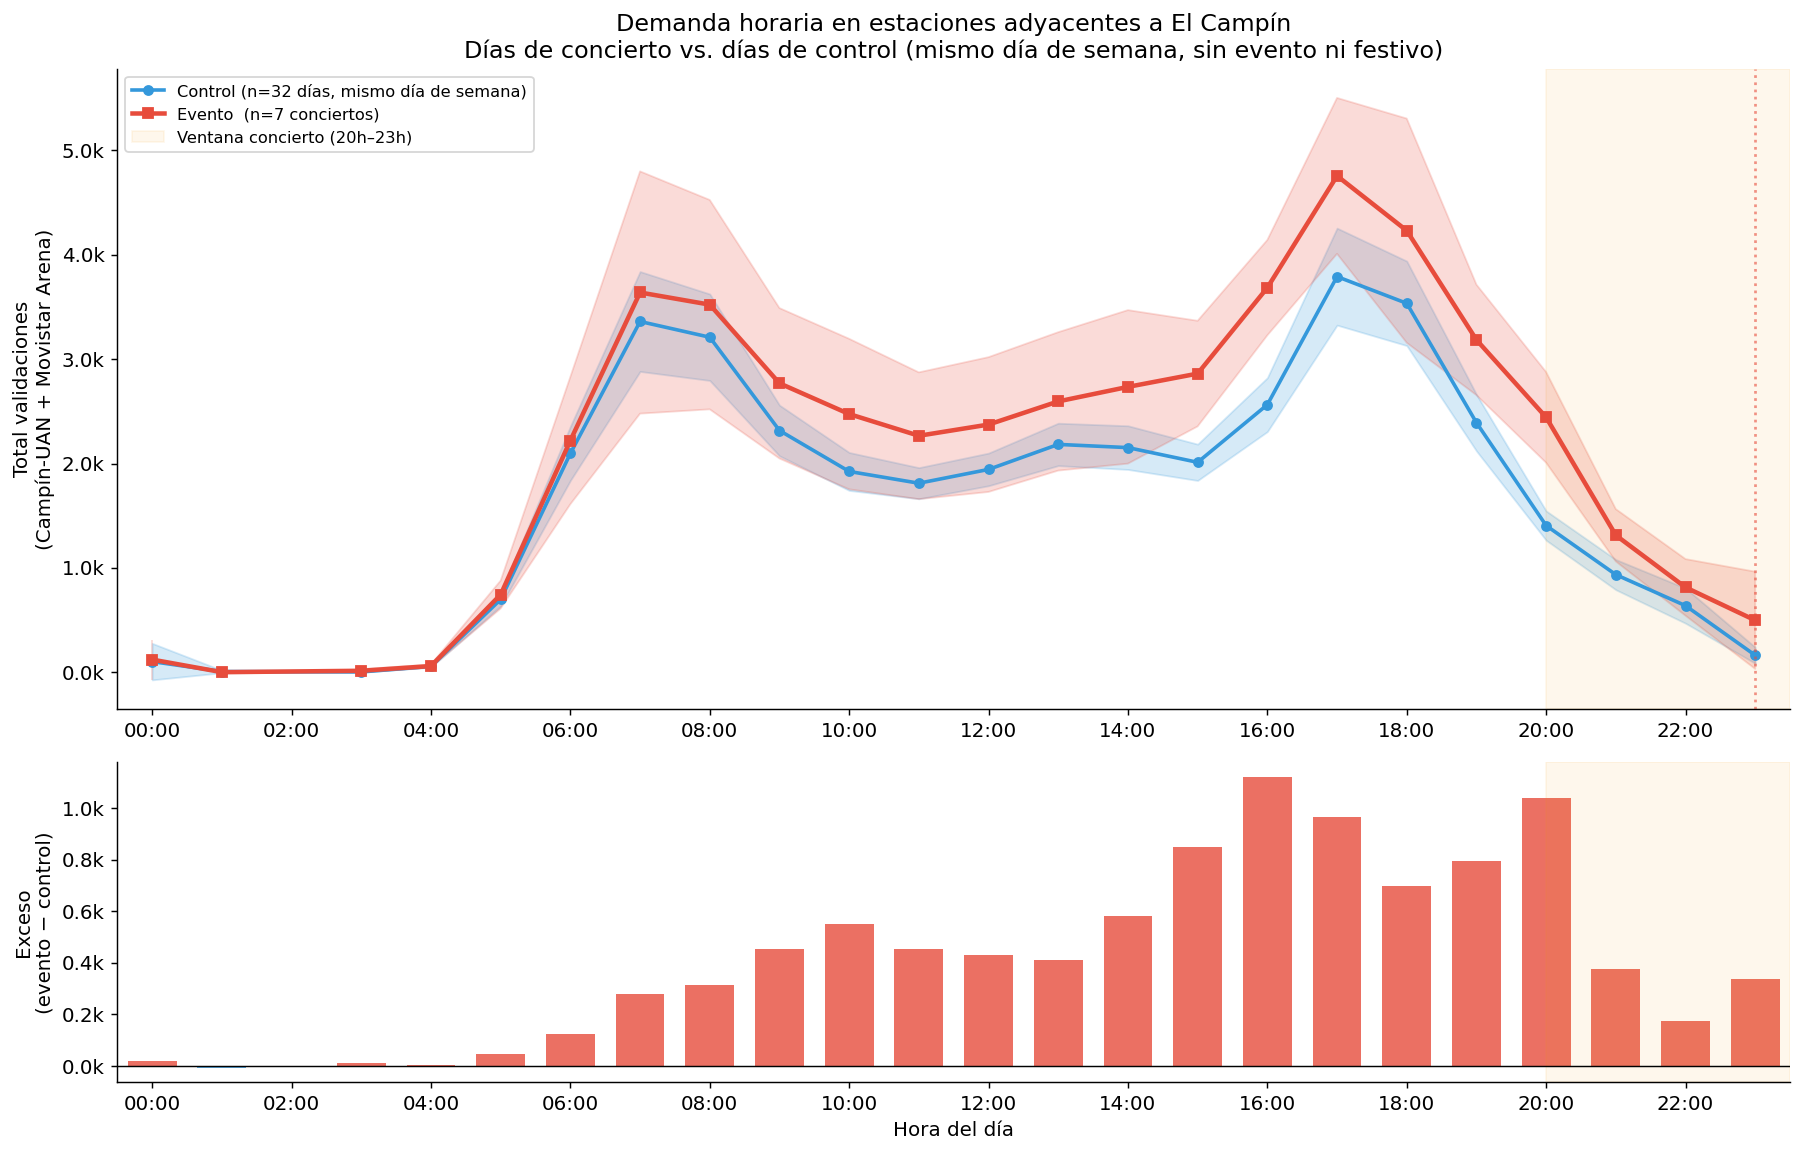

Figura guardada: reports/figures/campin_perfil_horario.png


In [6]:
panel_p = panel[panel.codigo_estacion.isin(TRAT_P)].copy()

# Total combinado de ambas estaciones primarias por fecha × hora
combined = (
    panel_p.groupby(['fecha', 'hora_int', 'event_d'])['total']
           .sum().reset_index()
)

def hour_profile(df, event_d_val):
    sub = df[df.event_d == event_d_val]
    stats = sub.groupby('hora_int')['total'].agg(['mean', 'std', 'count'])
    stats['se'] = stats['std'] / np.sqrt(stats['count'])
    return stats

ev_prof = hour_profile(combined, 1)
ct_prof = hour_profile(combined, 0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

# --- Panel superior: demanda por hora ---
ax1.fill_between(
    ct_prof.index,
    ct_prof['mean'] - 1.96 * ct_prof['se'],
    ct_prof['mean'] + 1.96 * ct_prof['se'],
    alpha=0.2, color='#3498db'
)
ax1.fill_between(
    ev_prof.index,
    ev_prof['mean'] - 1.96 * ev_prof['se'],
    ev_prof['mean'] + 1.96 * ev_prof['se'],
    alpha=0.2, color='#e74c3c'
)
n_ctrl = combined[combined.event_d == 0].fecha.nunique()
n_ev   = combined[combined.event_d == 1].fecha.nunique()
ax1.plot(ct_prof.index, ct_prof['mean'], 'o-', color='#3498db', ms=5, lw=2,
         label=f'Control (n={n_ctrl} días, mismo día de semana)')
ax1.plot(ev_prof.index, ev_prof['mean'], 's-', color='#e74c3c', ms=6, lw=2.5,
         label=f'Evento  (n={n_ev} conciertos)')

ax1.axvspan(20, 23.5, alpha=0.08, color='#f39c12', label='Ventana concierto (20h–23h)')
ax1.axvline(23, color='#e74c3c', ls=':', lw=1.5, alpha=0.6)
ax1.set_ylabel('Total validaciones\n(Campín-UAN + Movistar Arena)')
ax1.set_title(
    'Demanda horaria en estaciones adyacentes a El Campín\n'
    'Días de concierto vs. días de control (mismo día de semana, sin evento ni festivo)'
)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_xlim(-0.5, 23.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}k'))

# --- Panel inferior: exceso neto ---
excess = ev_prof['mean'] - ct_prof['mean']
colors_bar = ['#e74c3c' if x > 0 else '#3498db' for x in excess]
ax2.bar(excess.index, excess.values, color=colors_bar, alpha=0.8, width=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.axvspan(20, 23.5, alpha=0.08, color='#f39c12')
ax2.set_xlabel('Hora del día')
ax2.set_ylabel('Exceso\n(evento − control)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}k'))
ax2.set_xlim(-0.5, 23.5)

for ax in [ax1, ax2]:
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/campin_perfil_horario.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/campin_perfil_horario.png')

## 6. Event Study — Regresión hora a hora

Para cada hora $h \in \{0, 1, \ldots, 23\}$, se estima:

$$\log(\text{total}_{ih}) = \beta_h \cdot \text{evento}_d + \alpha_i + \varepsilon_{ih}$$

donde $\alpha_i$ son efectos fijos de estación (7105, 7106). El coeficiente $\beta_h$ captura el exceso de demanda en días de evento a la hora $h$, controlando por diferencias estructurales entre estaciones. La identificación es dentro de estación (within), en días del mismo día de semana.

In [7]:
panel_p = panel[panel.codigo_estacion.isin(TRAT_P)].copy()

betas = []
for h in range(0, 24):
    sub = panel_p[panel_p.hora_int == h].copy()
    # Necesitamos variación en event_d (ambas categorías presentes)
    if sub.event_d.nunique() < 2 or len(sub) < 6:
        betas.append({'h': h, 'b': np.nan, 'lo': np.nan, 'hi': np.nan, 'p': np.nan, 'pct': np.nan})
        continue
    try:
        ols_h = smf.ols('log_total ~ event_d + C(cod_str)', data=sub).fit(cov_type='HC3')
        if 'event_d' not in ols_h.params:
            raise ValueError('event_d not in params')
        ci = ols_h.conf_int().loc['event_d']
        b  = ols_h.params['event_d']
        betas.append({
            'h': h, 'b': b, 'lo': ci[0], 'hi': ci[1],
            'p': ols_h.pvalues['event_d'],
            'pct': (np.exp(b) - 1) * 100,
        })
    except Exception:
        betas.append({'h': h, 'b': np.nan, 'lo': np.nan, 'hi': np.nan, 'p': np.nan, 'pct': np.nan})

betas_df = pd.DataFrame(betas).set_index('h')

print(f"Event study — exceso de demanda por hora en días de concierto")
print(f"Estaciones: 7105 Movistar Arena + 7106 Campín-UAN")
print(f"Eventos: {n_ev} conciertos  |  Controles: {n_ctrl} días")
print()
print(f"{'h':>4}  {'β':>8}  {'IC 95%':>22}  {'% cambio':>10}  {'p-val':>7}  sig")
print("-" * 65)
for h, row in betas_df.iterrows():
    if np.isnan(row.b):
        continue
    sig = '***' if row.p < 0.01 else ('**' if row.p < 0.05 else ('*' if row.p < 0.1 else ''))
    print(f"  {h:02d}h  {row.b:+8.3f}  [{row.lo:+7.3f}, {row.hi:+7.3f}]  {row.pct:+9.1f}%  {row.p:.3f}   {sig}")

Event study — exceso de demanda por hora en días de concierto
Estaciones: 7105 Movistar Arena + 7106 Campín-UAN
Eventos: 7 conciertos  |  Controles: 32 días

   h         β                  IC 95%    % cambio    p-val  sig
-----------------------------------------------------------------
  00h    +0.948  [ +0.001,  +1.896]     +158.2%  0.050   **
  01h    -0.157  [   -inf,    +inf]      -14.5%  1.000   
  03h    +0.692  [ +0.068,  +1.315]      +99.7%  0.030   **
  04h    +0.091  [ -0.230,  +0.413]       +9.6%  0.578   
  05h    +0.070  [ -0.154,  +0.294]       +7.3%  0.538   
  06h    +0.057  [ -0.275,  +0.388]       +5.8%  0.738   
  07h    +0.090  [ -0.313,  +0.492]       +9.4%  0.663   
  08h    +0.103  [ -0.245,  +0.451]      +10.9%  0.561   
  09h    +0.176  [ -0.083,  +0.434]      +19.2%  0.183   
  10h    +0.224  [ -0.016,  +0.464]      +25.1%  0.068   *
  11h    +0.194  [ -0.016,  +0.404]      +21.4%  0.070   *
  12h    +0.172  [ -0.034,  +0.379]      +18.8%  0.101   
  13h    

## 7. Gráfico del event study horario

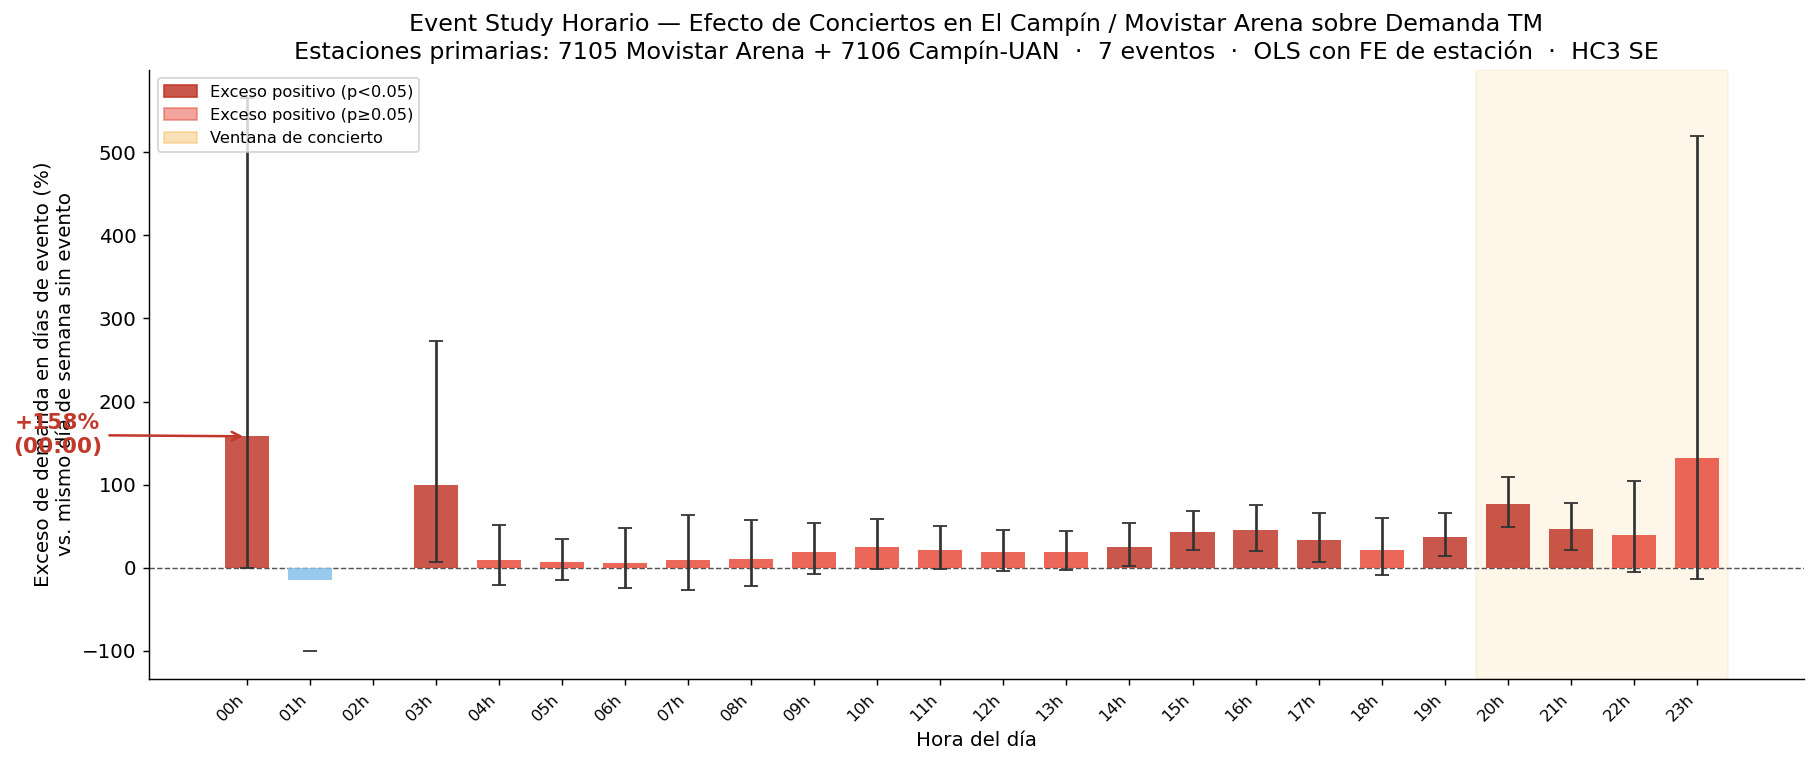

Figura guardada: reports/figures/campin_event_study.png


In [8]:
betas_plot = betas_df.dropna(subset=['b'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.axhline(0, color='#555', lw=0.8, ls='--')
ax.axvspan(19.5, 23.5, alpha=0.09, color='#f39c12', label='Ventana de concierto (20h–23h)')

# Colores por signo y significancia
bar_colors = [
    '#c0392b' if (row.pct > 0 and row.p < 0.05)
    else '#e74c3c' if (row.pct > 0)
    else '#2980b9' if (row.pct < 0 and row.p < 0.05)
    else '#85c1e9'
    for _, row in betas_plot.iterrows()
]

ax.bar(betas_plot.index, betas_plot.pct, color=bar_colors, alpha=0.85, width=0.7, zorder=2)

# Barras de error (CI 95%)
pct_lo = (np.exp(betas_plot.lo) - 1) * 100
pct_hi = (np.exp(betas_plot.hi) - 1) * 100
ax.errorbar(
    betas_plot.index, betas_plot.pct,
    yerr=[betas_plot.pct - pct_lo, pct_hi - betas_plot.pct],
    fmt='none', color='#333', capsize=4, lw=1.5, zorder=3
)

# Anotar el pico
peak_h   = int(betas_plot.pct.idxmax())
peak_val = betas_plot.pct.max()
ax.annotate(
    f'+{peak_val:.0f}%\n({peak_h:02d}:00)',
    xy=(peak_h, peak_val),
    xytext=(peak_h - 3, peak_val * 0.75 + 20),
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.4),
    color='#c0392b', fontweight='bold', fontsize=12, ha='center',
)

# Leyenda manual para colores
from matplotlib.patches import Patch
legend_elems = [
    Patch(color='#c0392b', alpha=0.85, label='Exceso positivo (p<0.05)'),
    Patch(color='#e74c3c', alpha=0.5,  label='Exceso positivo (p≥0.05)'),
    Patch(color='#f39c12', alpha=0.3,  label='Ventana de concierto'),
]
ax.legend(handles=legend_elems, fontsize=9, loc='upper left')

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}h' for h in range(0, 24)], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Exceso de demanda en días de evento (%)\nvs. mismo día de semana sin evento')
ax.set_title(
    f'Event Study Horario — Efecto de Conciertos en El Campín / Movistar Arena sobre Demanda TM\n'
    f'Estaciones primarias: 7105 Movistar Arena + 7106 Campín-UAN  ·  '
    f'{n_ev} eventos  ·  OLS con FE de estación  ·  HC3 SE'
)

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/campin_event_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/campin_event_study.png')

## 8. Análisis por evento individual

Comparación del perfil horario de cada concierto vs. la media de sus días de control equivalentes.

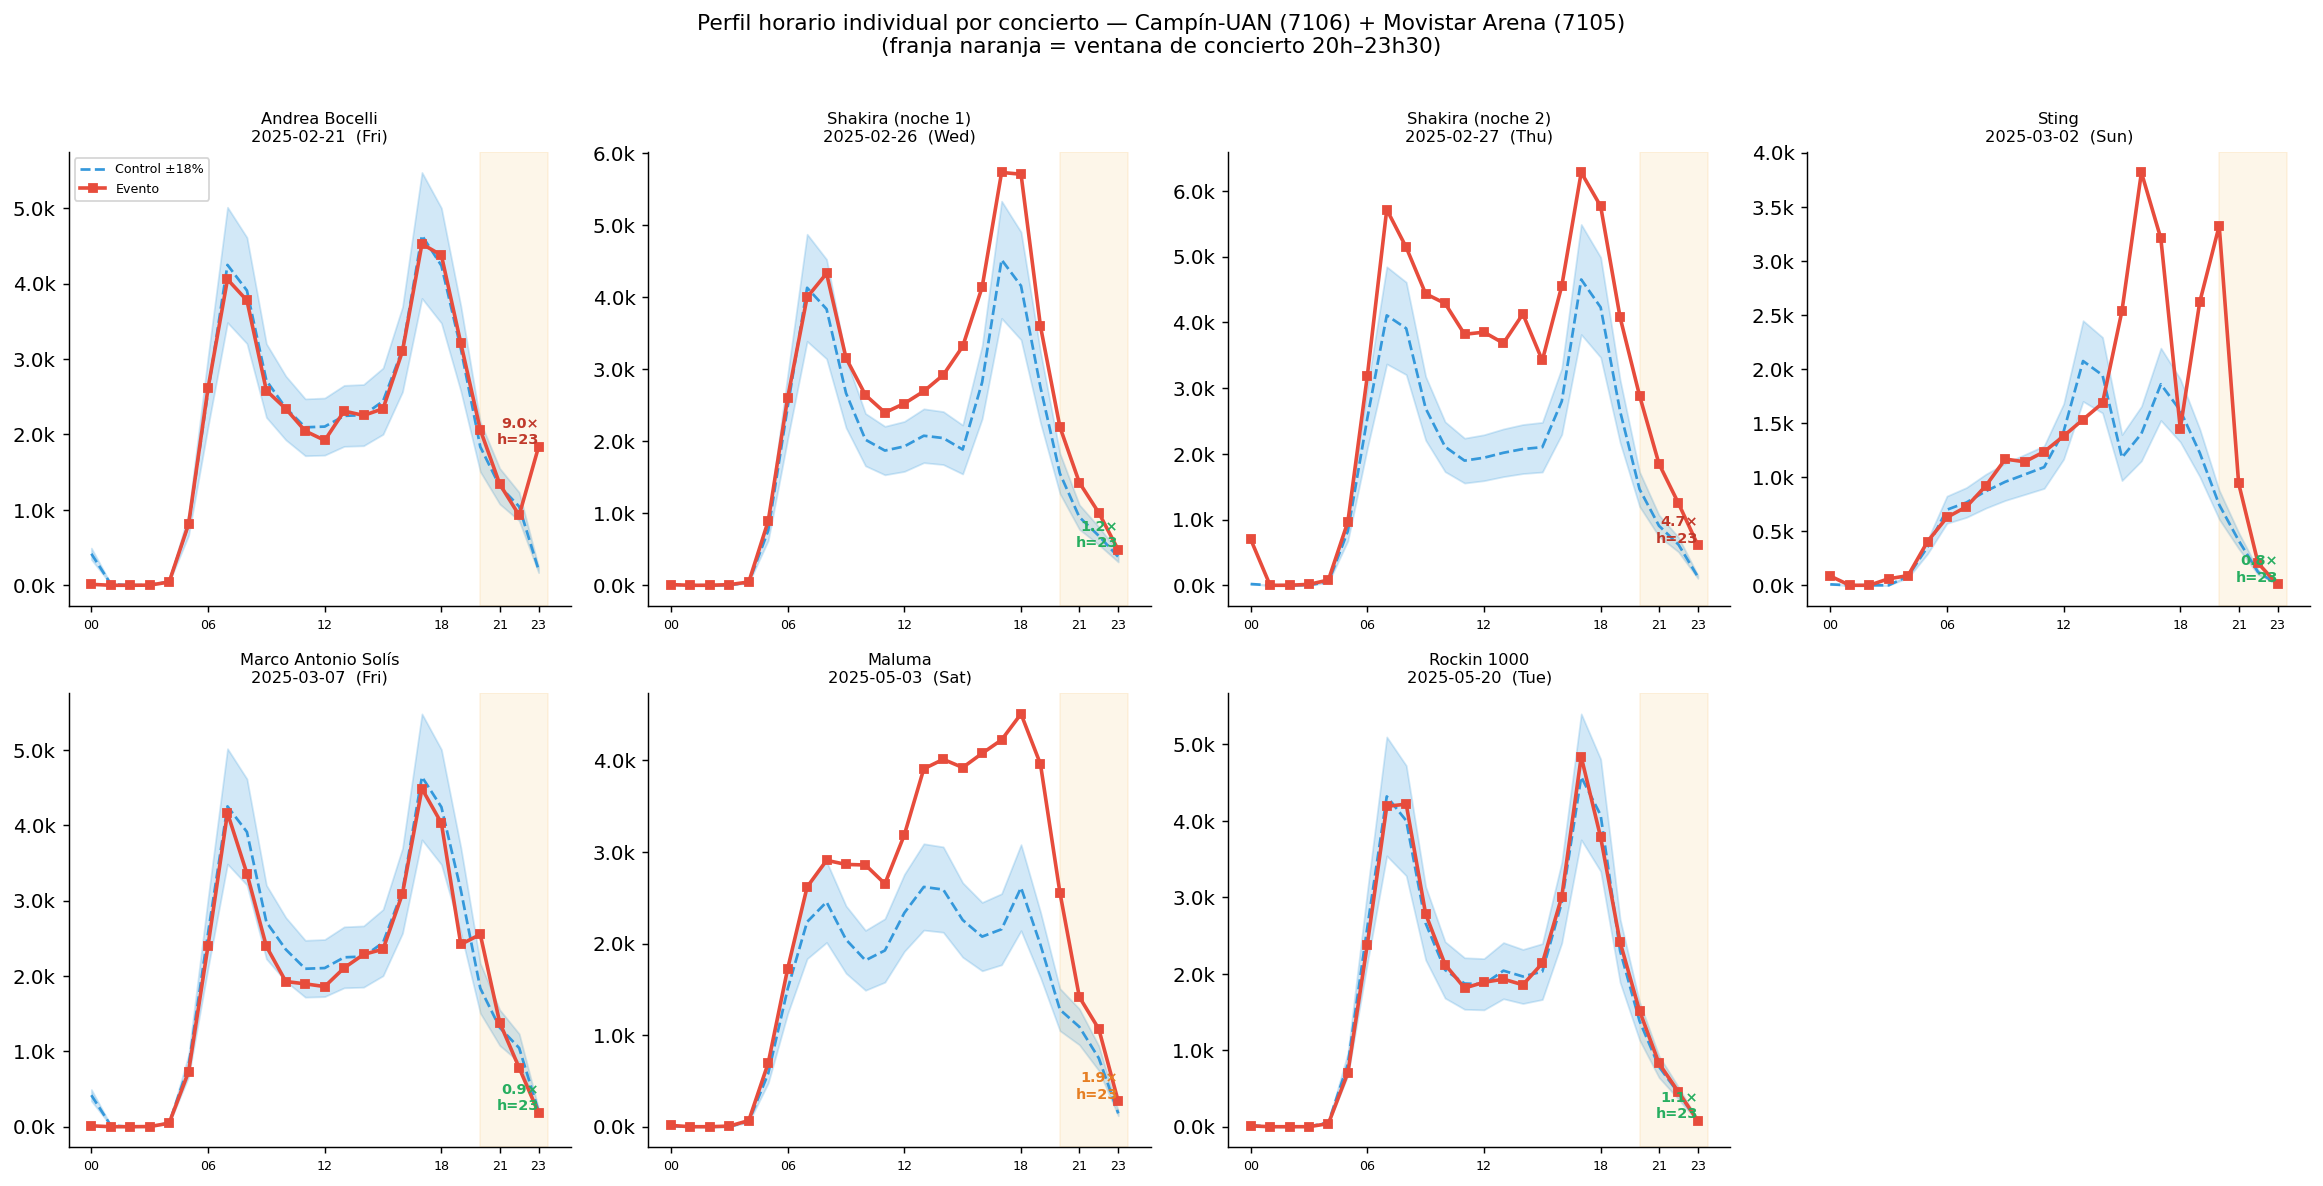

Figura guardada: reports/figures/campin_por_evento.png

Ratio de demanda a las 23:00 (evento / control):
Evento                        Evento h=23   Control h=23   Ratio
-----------------------------------------------------------------
Andrea Bocelli                      1,838            203    9.0×
Shakira (noche 2)                     608            128    4.7×
Maluma                                276            146    1.9×
Shakira (noche 1)                     491            394    1.2×
Rockin 1000                            77             72    1.1×
Marco Antonio Solís                   181            203    0.9×
Sting                                   8             10    0.8×


In [9]:
# Media de control por hora para cada DOW (solo estaciones primarias)
ctrl_dow_hour = {}
for dow in range(7):
    sub = panel_p[(panel_p.event_d == 0) & (panel_p.dow == dow)]
    if len(sub) == 0:
        continue
    combined_ctrl = sub.groupby(['fecha','hora_int'])['total'].sum()
    ctrl_dow_hour[dow] = combined_ctrl.groupby('hora_int').mean()

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes_flat = axes.flatten()

ratios_h23 = []
hours24 = np.arange(24)

for idx, (fecha, nombre) in enumerate(CONCIERTOS.items()):
    ax = axes_flat[idx]
    dow = pd.to_datetime(fecha).dayofweek

    # Suma de ambas estaciones primarias para ese día, alineada a índice 0-23
    ev_h = (
        panel_p[(panel_p.fecha == fecha) & (panel_p.codigo_estacion.isin(TRAT_P))]
        .groupby('hora_int')['total'].sum()
        .reindex(hours24, fill_value=0)
    )
    ct_h = ctrl_dow_hour.get(dow, pd.Series(dtype=float)).reindex(hours24, fill_value=0)

    # Plot
    ax.fill_between(hours24, ct_h.values * 0.82, ct_h.values * 1.18, alpha=0.22, color='#3498db')
    ax.plot(hours24, ct_h.values, '--', color='#3498db', lw=1.5, label='Control ±18%')
    ax.plot(hours24, ev_h.values, 's-', color='#e74c3c', ms=4, lw=2, label='Evento')

    ax.axvspan(20, 23.5, alpha=0.09, color='#f39c12')
    ax.set_title(f'{nombre}\n{fecha}  ({pd.to_datetime(fecha).day_name()[:3]})', fontsize=9)
    ax.set_xticks([0, 6, 12, 18, 21, 23])
    ax.set_xticklabels(['00', '06', '12', '18', '21', '23'], fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}k'))

    # Anotar ratio a h=23
    ev23 = ev_h.get(23, 0)
    ct23 = ct_h.get(23, 0)
    if ct23 > 0:
        ratio23 = ev23 / ct23
        ratios_h23.append({'evento': nombre, 'fecha': fecha, 'ev23': ev23, 'ct23': ct23, 'ratio': ratio23})
        color23 = '#c0392b' if ratio23 > 3 else ('#e67e22' if ratio23 > 1.5 else '#27ae60')
        ax.annotate(
            f'{ratio23:.1f}×\nh=23',
            xy=(23, ev_h.iloc[23]), fontsize=8, color=color23,
            fontweight='bold', ha='right', va='bottom'
        )

axes_flat[0].legend(fontsize=7, loc='upper left')

# Ocultar subplot vacío (7 eventos, 8 celdas)
axes_flat[-1].set_visible(False)

fig.suptitle(
    'Perfil horario individual por concierto — Campín-UAN (7106) + Movistar Arena (7105)\n'
    '(franja naranja = ventana de concierto 20h–23h30)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/campin_por_evento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/campin_por_evento.png')

# Tabla de ratios h=23
print()
print('Ratio de demanda a las 23:00 (evento / control):')
print(f'{"Evento":<28} {"Evento h=23":>12} {"Control h=23":>14} {"Ratio":>7}')
print('-' * 65)
for r in sorted(ratios_h23, key=lambda x: -x['ratio']):
    print(f"{r['evento']:<28} {r['ev23']:>12,.0f} {r['ct23']:>14,.0f} {r['ratio']:>6.1f}×")

## 9. Análisis de spillover — ¿Cuántas estaciones y a qué distancia?

Replicamos el mismo event study para todas las estaciones hasta 3 km, agrupadas por distancia al estadio.

Efecto por franja de distancia y hora:
Franja                 Hora        β   % cambio   p-val  n_est  sig
----------------------------------------------------------------------
≤500 m
(primaria)        20h   +0.569     +76.7%   0.000      2  ***
≤500 m
(primaria)        21h   +0.383     +46.7%   0.000      2  ***
≤500 m
(primaria)        22h   +0.333     +39.6%   0.086      2  *
≤500 m
(primaria)        23h   +0.842    +132.0%   0.093      2  *
500–1500 m
(secundar     20h   +0.146     +15.7%   0.180      3  
500–1500 m
(secundar     21h   +0.114     +12.1%   0.310      3  
500–1500 m
(secundar     22h   +0.079      +8.2%   0.613      3  
500–1500 m
(secundar     23h   +0.128     +13.7%   0.627      3  
1500–3000 m
(terciar     20h   +0.107     +11.3%   0.046     16  **
1500–3000 m
(terciar     21h   +0.090      +9.4%   0.093     16  *
1500–3000 m
(terciar     22h   +0.108     +11.4%   0.077     16  *
1500–3000 m
(terciar     23h   +0.129     +13.8%   0.118     16  


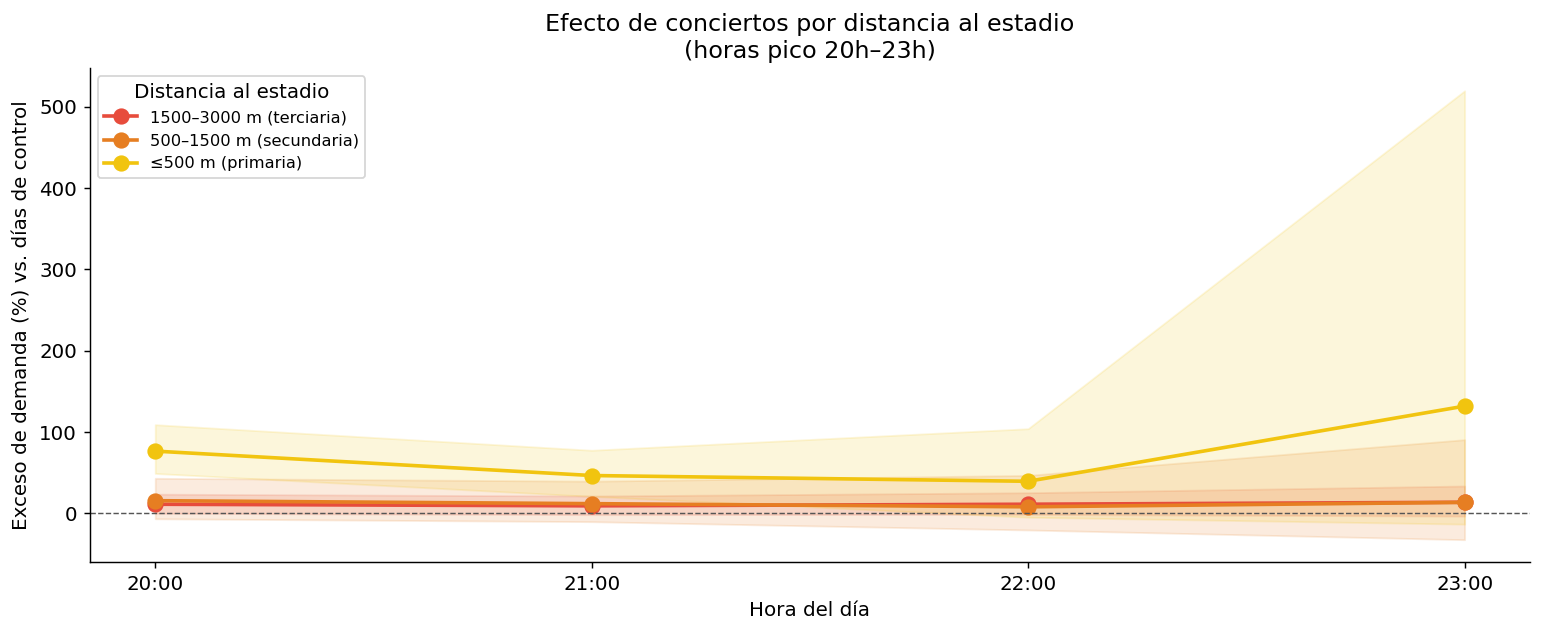

Figura guardada: reports/figures/campin_spillover_distancia.png


In [10]:
# Unir distancias al panel completo
dist_map = stations_m.set_index('codigo_estacion')['dist_m'].to_dict()
panel['dist_m'] = panel.codigo_estacion.map(dist_map)

# Bins de distancia
bins   = [0, 500, 1500, 3000]
labels = ['≤500 m\n(primaria)', '500–1500 m\n(secundaria)', '1500–3000 m\n(terciaria)']
panel['dist_bin'] = pd.cut(panel.dist_m, bins=bins, labels=labels)

# Para cada bin, estimar β_h (exceso a las 23h, el pico)
spillover = []
for label, grp in panel.groupby('dist_bin', observed=True):
    for h in [20, 21, 22, 23]:
        sub = grp[grp.hora_int == h].copy()
        if sub.event_d.nunique() < 2 or len(sub) < 6:
            continue
        try:
            ols_h = smf.ols('log_total ~ event_d + C(cod_str)', data=sub).fit(cov_type='HC3')
            if 'event_d' not in ols_h.params: continue
            b  = ols_h.params['event_d']
            ci = ols_h.conf_int().loc['event_d']
            spillover.append({
                'dist_bin': label, 'h': h, 'b': b,
                'lo': ci[0], 'hi': ci[1],
                'p': ols_h.pvalues['event_d'],
                'pct': (np.exp(b) - 1) * 100,
                'n_est': sub.codigo_estacion.nunique(),
            })
        except Exception:
            pass

sp_df = pd.DataFrame(spillover)

print('Efecto por franja de distancia y hora:')
print(f'{"Franja":<22} {"Hora":>4} {"β":>8} {"% cambio":>10} {"p-val":>7} {"n_est":>6}  sig')
print('-' * 70)
for _, r in sp_df.iterrows():
    sig = '***' if r.p < 0.01 else ('**' if r.p < 0.05 else ('*' if r.p < 0.1 else ''))
    print(f"{str(r.dist_bin)[:20]:<22} {r.h:>4d}h {r.b:+8.3f} {r.pct:+9.1f}% {r.p:>7.3f} {r.n_est:>6.0f}  {sig}")

# Plot comparativo
fig, ax = plt.subplots(figsize=(12, 5))
colors_sp = ['#e74c3c', '#e67e22', '#f1c40f']
for idx, (label, grp_sp) in enumerate(sp_df.groupby('dist_bin', observed=True)):
    ax.plot(grp_sp.h, grp_sp.pct, 'o-', color=colors_sp[idx], ms=8, lw=2,
            label=str(label).replace('\n', ' '))
    ax.fill_between(
        grp_sp.h,
        (np.exp(grp_sp.lo) - 1) * 100,
        (np.exp(grp_sp.hi) - 1) * 100,
        alpha=0.15, color=colors_sp[idx]
    )

ax.axhline(0, color='#555', lw=0.8, ls='--')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Exceso de demanda (%) vs. días de control')
ax.set_title('Efecto de conciertos por distancia al estadio\n(horas pico 20h–23h)')
ax.legend(title='Distancia al estadio', fontsize=9)
ax.set_xticks([20, 21, 22, 23])
ax.set_xticklabels(['20:00', '21:00', '22:00', '23:00'])

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/campin_spillover_distancia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/campin_spillover_distancia.png')

## 10. Extensión: Festival de Verano (2–10 agosto)

Festival de Verano: 8 días de evento (2025-08-02, 2025-08-03, 2025-08-04, 2025-08-05, 2025-08-06, 2025-08-08, 2025-08-09, 2025-08-10)
Nota: 2025-08-07 excluido (festivo — Batalla de Boyacá)
Controles: 24 fechas


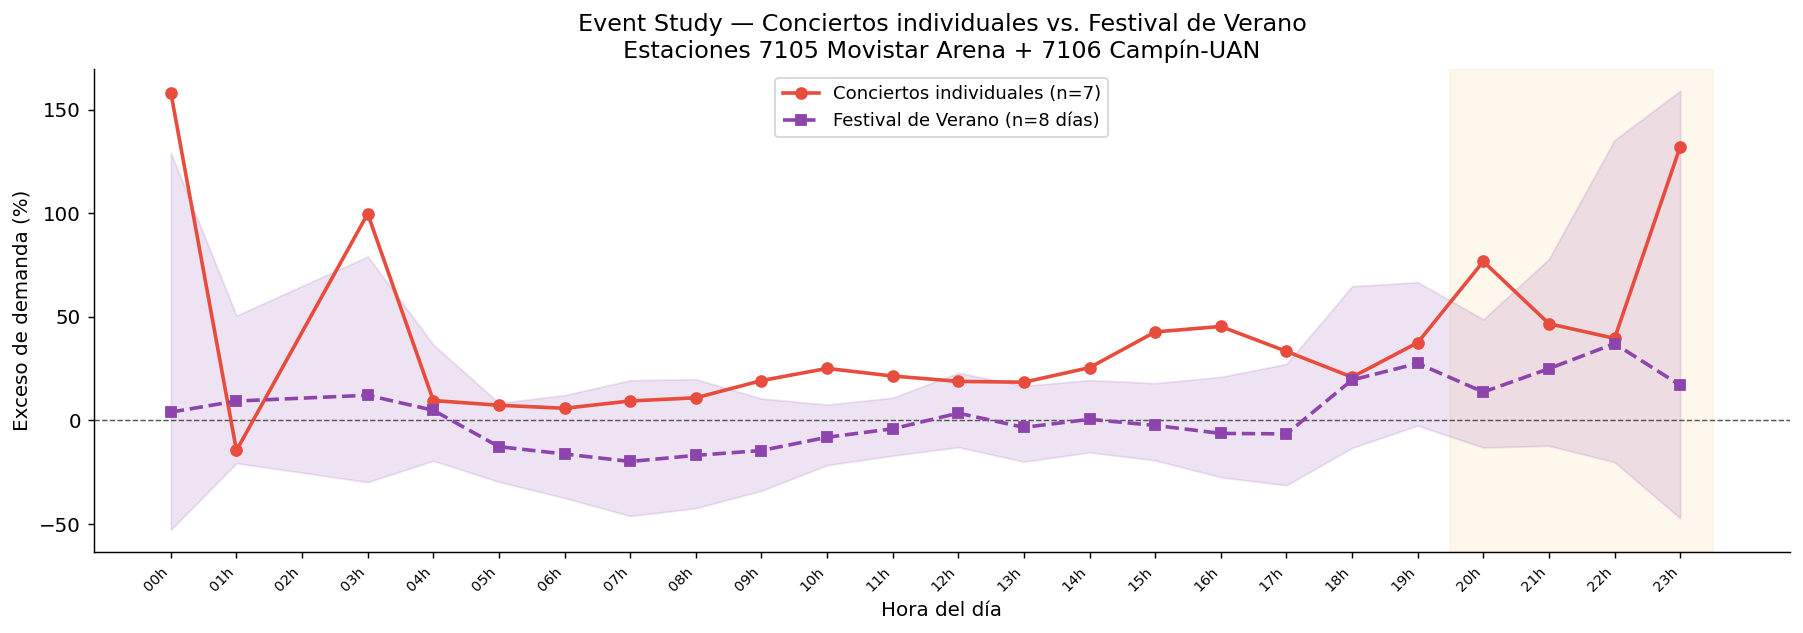

Figura guardada: reports/figures/campin_conciertos_vs_fdv.png


In [11]:
# Cargar días del Festival de Verano
# Control: mismos DOW del año sin evento (excluir festivos)
fdv_dates = [d for d in FESTIVAL_VERANO if d not in FESTIVOS]

fdv_dows = {pd.to_datetime(d).dayofweek for d in fdv_dates}
ctrl_fdv = set()
for dow in fdv_dows:
    cands = [
        d for d in all_dates
        if d.dayofweek == dow
        and str(d.date()) not in TODOS_EVENTOS
        and str(d.date()) not in FESTIVOS
    ]
    cands_sorted = sorted(cands, key=lambda d: min(abs((d - pd.to_datetime(ev)).days) for ev in fdv_dates if pd.to_datetime(ev).dayofweek == dow))
    ctrl_fdv.update([str(d.date()) for d in cands_sorted[:4]])

print(f"Festival de Verano: {len(fdv_dates)} días de evento ({', '.join(fdv_dates)})")
print(f"Nota: 2025-08-07 excluido (festivo — Batalla de Boyacá)")
print(f"Controles: {len(ctrl_fdv)} fechas")

# Cargar parquets de FdV
fdv_rows  = [load_hourly(f, CODES_ALL) for f in fdv_dates]
ctrlf_rows = [load_hourly(f, CODES_ALL) for f in sorted(ctrl_fdv)]

df_fdv  = pd.concat(fdv_rows,  ignore_index=True)
df_fdv['event_d'] = 1
df_ctrlfv = pd.concat(ctrlf_rows, ignore_index=True)
df_ctrlfv['event_d'] = 0

panel_fdv = pd.concat([df_fdv, df_ctrlfv], ignore_index=True)
panel_fdv['log_total'] = np.log(panel_fdv.total.clip(lower=1))
panel_fdv['cod_str']   = panel_fdv.codigo_estacion.astype(str)
panel_fdv_p = panel_fdv[panel_fdv.codigo_estacion.isin(TRAT_P)].copy()

# Event study horario para FdV
betas_fdv = []
for h in range(0, 24):
    sub = panel_fdv_p[panel_fdv_p.hora_int == h].copy()
    if sub.event_d.nunique() < 2 or len(sub) < 6:
        betas_fdv.append({'h': h, 'b': np.nan, 'lo': np.nan, 'hi': np.nan, 'p': np.nan, 'pct': np.nan})
        continue
    try:
        ols_h = smf.ols('log_total ~ event_d + C(cod_str)', data=sub).fit(cov_type='HC3')
        if 'event_d' not in ols_h.params: raise ValueError
        ci = ols_h.conf_int().loc['event_d']
        b  = ols_h.params['event_d']
        betas_fdv.append({'h': h, 'b': b, 'lo': ci[0], 'hi': ci[1],
                          'p': ols_h.pvalues['event_d'], 'pct': (np.exp(b)-1)*100})
    except Exception:
        betas_fdv.append({'h': h, 'b': np.nan, 'lo': np.nan, 'hi': np.nan, 'p': np.nan, 'pct': np.nan})

betas_fdv_df = pd.DataFrame(betas_fdv).set_index('h').dropna(subset=['b'])

# Comparar gráficamente: conciertos vs. Festival de Verano
fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color='#555', lw=0.8, ls='--')
ax.axvspan(19.5, 23.5, alpha=0.08, color='#f39c12')

betas_plot2 = betas_df.dropna(subset=['b'])

ax.plot(betas_plot2.index,   betas_plot2.pct,   'o-', color='#e74c3c', ms=6, lw=2, label='Conciertos individuales (n=7)')
ax.plot(betas_fdv_df.index, betas_fdv_df.pct,  's--', color='#8e44ad', ms=6, lw=2, label=f'Festival de Verano (n={len(fdv_dates)} días)')

ax.fill_between(betas_fdv_df.index,
                (np.exp(betas_fdv_df.lo)-1)*100,
                (np.exp(betas_fdv_df.hi)-1)*100,
                alpha=0.15, color='#8e44ad')

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}h' for h in range(0, 24)], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Exceso de demanda (%)')
ax.set_title(
    'Event Study — Conciertos individuales vs. Festival de Verano\n'
    'Estaciones 7105 Movistar Arena + 7106 Campín-UAN'
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/campin_conciertos_vs_fdv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/campin_conciertos_vs_fdv.png')

## 10b. Festival de Verano — Análisis detallado

El Festival de Verano de Bogotá (FdV) difiere estructuralmente de un concierto individual:
- Es un festival de **8 días continuos** (2–10 ago, excluyendo el festivo del 7) con múltiples escenarios simultáneos repartidos por la ciudad.
- Incluye tanto días de **fin de semana** (alta demanda base, público amplio) como **días hábiles** (menor demanda base, asistentes más selectivos).
- Los eventos pueden ser diurnos, vespertinos y nocturnos — el patrón horario podría ser más distribuido que el pico único a h=23 de los conciertos.

Preguntas a responder:
1. ¿Cuál es el perfil horario del FdV y en qué horas es significativo?
2. ¿Se diferencia entre días de fin de semana y días hábiles del FdV?
3. ¿El efecto total (pico h=20–23) es estadísticamente distinto al de los conciertos individuales?

In [12]:
# Tabla de coeficientes del event study del FdV
print("Event Study horario — Festival de Verano 2025")
print(f"Estaciones: 7105 Movistar Arena + 7106 Campín-UAN")
print(f"Eventos: {len(fdv_dates)} días de FdV ({', '.join(fdv_dates)})")
print()
print(f"{'h':>4}  {'β':>8}  {'IC 95%':>22}  {'% cambio':>10}  {'p-val':>7}  sig")
print("-" * 65)
for h, row in betas_fdv_df.iterrows():
    sig = '***' if row.p < 0.01 else ('**' if row.p < 0.05 else ('*' if row.p < 0.1 else ''))
    print(f"  {h:02d}h  {row.b:+8.3f}  [{row.lo:+7.3f}, {row.hi:+7.3f}]  {row.pct:+9.1f}%  {row.p:.3f}   {sig}")

Event Study horario — Festival de Verano 2025
Estaciones: 7105 Movistar Arena + 7106 Campín-UAN
Eventos: 8 días de FdV (2025-08-02, 2025-08-03, 2025-08-04, 2025-08-05, 2025-08-06, 2025-08-08, 2025-08-09, 2025-08-10)

   h         β                  IC 95%    % cambio    p-val  sig
-----------------------------------------------------------------
  00h    +0.039  [ -0.751,  +0.829]       +4.0%  0.923   
  01h    +0.089  [ -0.231,  +0.409]       +9.3%  0.585   
  03h    +0.114  [ -0.354,  +0.583]      +12.1%  0.632   
  04h    +0.047  [ -0.216,  +0.311]       +4.9%  0.725   
  05h    -0.136  [ -0.352,  +0.080]      -12.7%  0.218   
  06h    -0.177  [ -0.469,  +0.115]      -16.2%  0.235   
  07h    -0.221  [ -0.619,  +0.177]      -19.8%  0.276   
  08h    -0.185  [ -0.551,  +0.181]      -16.9%  0.322   
  09h    -0.157  [ -0.415,  +0.100]      -14.5%  0.231   
  10h    -0.085  [ -0.244,  +0.074]       -8.1%  0.293   
  11h    -0.042  [ -0.186,  +0.103]       -4.1%  0.575   
  12h    +0.03

In [13]:
# Clasificar días del FdV en fin de semana vs. días hábiles
fdv_fds    = [d for d in fdv_dates if pd.to_datetime(d).dayofweek in (5, 6)]   # sáb, dom
fdv_hab    = [d for d in fdv_dates if pd.to_datetime(d).dayofweek not in (5, 6)]
print(f"FdV fin de semana : {fdv_fds}")
print(f"FdV días hábiles  : {fdv_hab}")

def event_study_subset(ev_dates, ctrl_dates_pool, label):
    """Corre el event study horario para un subconjunto de días de FdV."""
    ev_rows_s  = [load_hourly(f, CODES_ALL) for f in ev_dates]
    df_ev_s    = pd.concat(ev_rows_s, ignore_index=True)
    df_ev_s['event_d'] = 1

    # Controles del mismo DOW
    dows = {pd.to_datetime(d).dayofweek for d in ev_dates}
    ctrl_sub = [f for f in ctrl_dates_pool if pd.to_datetime(f).dayofweek in dows]
    ct_rows_s = [load_hourly(f, CODES_ALL) for f in ctrl_sub]
    df_ct_s   = pd.concat(ct_rows_s, ignore_index=True)
    df_ct_s['event_d'] = 0

    pan = pd.concat([df_ev_s, df_ct_s], ignore_index=True)
    pan['log_total'] = np.log(pan.total.clip(lower=1))
    pan['cod_str']   = pan.codigo_estacion.astype(str)
    pan_p = pan[pan.codigo_estacion.isin(TRAT_P)].copy()

    betas_s = []
    for h in range(0, 24):
        sub = pan_p[pan_p.hora_int == h].copy()
        if sub.event_d.nunique() < 2 or len(sub) < 4:
            betas_s.append({'h': h, 'b': np.nan, 'lo': np.nan, 'hi': np.nan, 'p': np.nan, 'pct': np.nan})
            continue
        try:
            ols_h = smf.ols('log_total ~ event_d + C(cod_str)', data=sub).fit(cov_type='HC3')
            if 'event_d' not in ols_h.params: raise ValueError
            ci = ols_h.conf_int().loc['event_d']
            b  = ols_h.params['event_d']
            betas_s.append({'h': h, 'b': b, 'lo': ci[0], 'hi': ci[1],
                            'p': ols_h.pvalues['event_d'], 'pct': (np.exp(b)-1)*100})
        except Exception:
            betas_s.append({'h': h, 'b': np.nan, 'lo': np.nan, 'hi': np.nan, 'p': np.nan, 'pct': np.nan})
    return pd.DataFrame(betas_s).set_index('h').dropna(subset=['b'])

# Controles ya cargados — usamos el conjunto completo de ctrl_fdv
betas_fds = event_study_subset(fdv_fds, sorted(ctrl_fdv), 'FdV fin de semana')
betas_hab = event_study_subset(fdv_hab, sorted(ctrl_fdv), 'FdV días hábiles')

print(f"\nListo: fin de semana n={len(fdv_fds)} días, hábiles n={len(fdv_hab)} días")

FdV fin de semana : ['2025-08-02', '2025-08-03', '2025-08-09', '2025-08-10']
FdV días hábiles  : ['2025-08-04', '2025-08-05', '2025-08-06', '2025-08-08']



Listo: fin de semana n=4 días, hábiles n=4 días


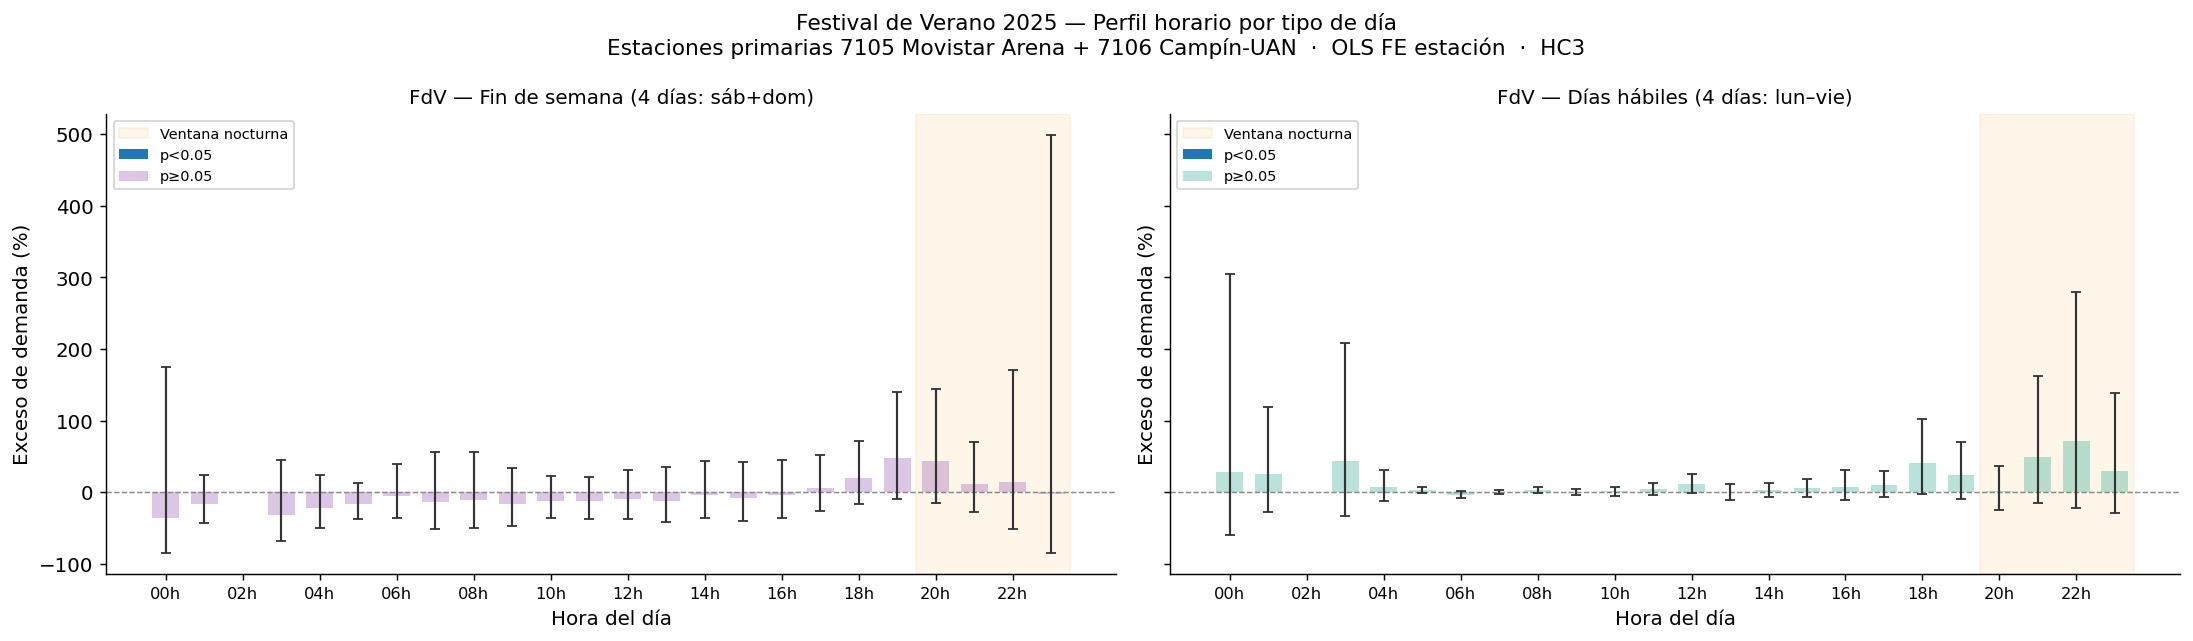

Figura guardada: reports/figures/fdv_perfil_horario_tipo_dia.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)

specs = [
    (axes[0], betas_fds, '#8e44ad', f'FdV — Fin de semana ({len(fdv_fds)} días: sáb+dom)'),
    (axes[1], betas_hab, '#16a085', f'FdV — Días hábiles ({len(fdv_hab)} días: lun–vie)'),
]

for ax, bdf, color, title in specs:
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.axvspan(19.5, 23.5, alpha=0.09, color='#f39c12', label='Ventana nocturna')

    sig_mask  = bdf.p < 0.05
    insig_mask = ~sig_mask
    ax.bar(bdf.index[sig_mask],  bdf.pct[sig_mask],  color=color, alpha=0.85, width=0.7, label='p<0.05')
    ax.bar(bdf.index[insig_mask], bdf.pct[insig_mask], color=color, alpha=0.30, width=0.7, label='p≥0.05')

    # Barras de error
    pct_lo = (np.exp(bdf.lo) - 1) * 100
    pct_hi = (np.exp(bdf.hi) - 1) * 100
    ax.errorbar(bdf.index, bdf.pct,
                yerr=[bdf.pct - pct_lo, pct_hi - bdf.pct],
                fmt='none', color='#333', capsize=3, lw=1.2, zorder=3)

    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}h' for h in range(0, 24, 2)], fontsize=9)
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Exceso de demanda (%)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle(
    'Festival de Verano 2025 — Perfil horario por tipo de día\n'
    'Estaciones primarias 7105 Movistar Arena + 7106 Campín-UAN  ·  OLS FE estación  ·  HC3',
    fontsize=12
)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/fdv_perfil_horario_tipo_dia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/fdv_perfil_horario_tipo_dia.png')

In [15]:
# Ratio por día individual del FdV a h=20 y h=23
# Mediana de control por DOW × hora
ctrl_fdv_panel = panel_fdv[panel_fdv.event_d == 0]
ctrl_fdv_med = (
    ctrl_fdv_panel[ctrl_fdv_panel.codigo_estacion.isin(TRAT_P)]
    .assign(dow=lambda x: pd.to_datetime(x.fecha).dt.dayofweek)
    .groupby(['dow', 'hora_int'])
    .agg(total_ctrl=('total', 'mean'))
    .reset_index()
)

print(f"Perfil por día individual del FdV (estaciones primarias, h=20 y h=23):\n")
print(f"{'Fecha':<12} {'Día':<3}  {'val h=20':>10}  {'ctrl h=20':>10}  {'ratio h=20':>11}  │  {'val h=23':>10}  {'ctrl h=23':>10}  {'ratio h=23':>11}")
print("─" * 90)

fdv_day_ratios = []
for d in fdv_dates:
    dt = pd.to_datetime(d)
    dow = dt.dayofweek
    ev_h = (
        panel_fdv[
            (panel_fdv.fecha == d) &
            (panel_fdv.codigo_estacion.isin(TRAT_P))
        ]
        .groupby('hora_int')['total'].sum()
    )
    def get_ctrl(h):
        row = ctrl_fdv_med[(ctrl_fdv_med.dow == dow) & (ctrl_fdv_med.hora_int == h)]
        return row['total_ctrl'].values[0] * len(TRAT_P) if len(row) else np.nan

    v20 = ev_h.get(20, 0);  c20 = get_ctrl(20)
    v23 = ev_h.get(23, 0);  c23 = get_ctrl(23)
    r20 = v20 / c20 if c20 and c20 > 0 else np.nan
    r23 = v23 / c23 if c23 and c23 > 0 else np.nan
    tipo = 'fds' if dow in (5, 6) else 'hab'
    fdv_day_ratios.append({'fecha': d, 'dow': dt.day_name()[:3], 'tipo': tipo,
                            'v20': v20, 'c20': c20, 'r20': r20,
                            'v23': v23, 'c23': c23, 'r23': r23})
    print(f"{d}  {dt.day_name()[:3]}  {v20:>10,.0f}  {c20:>10,.0f}  {r20:>10.2f}×  │  "
          f"{v23:>10,.0f}  {c23:>10,.0f}  {r23:>10.2f}×")

fdv_dr = pd.DataFrame(fdv_day_ratios)
print(f"\nMedia ratio h=20: fds={fdv_dr[fdv_dr.tipo=='fds']['r20'].mean():.2f}×  hábil={fdv_dr[fdv_dr.tipo=='hab']['r20'].mean():.2f}×")
print(f"Media ratio h=23: fds={fdv_dr[fdv_dr.tipo=='fds']['r23'].mean():.2f}×  hábil={fdv_dr[fdv_dr.tipo=='hab']['r23'].mean():.2f}×")

Perfil por día individual del FdV (estaciones primarias, h=20 y h=23):

Fecha        Día    val h=20   ctrl h=20   ratio h=20  │    val h=23   ctrl h=23   ratio h=23
──────────────────────────────────────────────────────────────────────────────────────────
2025-08-02  Sat       2,730       2,105        1.30×  │       1,898       1,926        0.99×
2025-08-03  Sun         980         665        1.47×  │         128          27        4.79×
2025-08-04  Mon       1,176       1,283        0.92×  │          67         118        0.57×
2025-08-05  Tue       1,427       2,351        0.61×  │          74          83        0.89×
2025-08-06  Wed       2,707       1,471        1.84×  │         339         153        2.22×
2025-08-08  Fri       1,597       1,991        0.80×  │         222         186        1.20×
2025-08-09  Sat       1,900       2,105        0.90×  │         145       1,926        0.08×
2025-08-10  Sun       1,471         665        2.21×  │          12          27        0.45×

In [16]:
# Comparación formal FdV vs. conciertos en horas pico (h=20, h=23)
# Construimos un panel unificado: tipo = 'concierto' | 'fdv', event_d = 1 | 0
panel_conc = panel[panel.codigo_estacion.isin(TRAT_P)].copy()
panel_conc['tipo_evento'] = 'concierto'

panel_fdv_p2 = panel_fdv[panel_fdv.codigo_estacion.isin(TRAT_P)].copy()
panel_fdv_p2['tipo_evento'] = 'fdv'

panel_uni = pd.concat([panel_conc, panel_fdv_p2], ignore_index=True)
panel_uni['log_total'] = np.log(panel_uni.total.clip(lower=1))
panel_uni['cod_str']   = panel_uni.codigo_estacion.astype(str)

print("Comparación FdV vs. conciertos individuales en horas pico:\n")
print(f"{'Hora':<6}  {'β_conc':>8}  {'% conc':>8}  {'β_fdv':>8}  {'% fdv':>8}  {'Dif (pp)':>10}  {'F':>6}  {'p':>7}  sig")
print("─" * 75)

for h_cmp in [18, 19, 20, 21, 22, 23]:
    sub = panel_uni[panel_uni.hora_int == h_cmp].copy()
    if sub.event_d.nunique() < 2 or len(sub) < 8:
        continue

    # Interacción: event_d + fdv_flag + event_d:fdv_flag
    sub['fdv_flag'] = (sub.tipo_evento == 'fdv').astype(int)
    try:
        ols_cmp = smf.ols(
            'log_total ~ event_d + fdv_flag + event_d:fdv_flag + C(cod_str)',
            data=sub
        ).fit(cov_type='HC3')
    except Exception as e:
        print(f"  {h_cmp:02d}h  ERROR: {e}")
        continue

    b_conc = ols_cmp.params.get('event_d', np.nan)
    b_int  = ols_cmp.params.get('event_d:fdv_flag', np.nan)
    if np.isnan(b_conc) or np.isnan(b_int):
        continue
    b_fdv  = b_conc + b_int

    pct_c = (np.exp(b_conc) - 1) * 100
    pct_f = (np.exp(b_fdv) - 1) * 100
    dif   = pct_f - pct_c

    f_res  = ols_cmp.f_test('event_d:fdv_flag = 0')
    fval   = float(np.atleast_1d(f_res.fvalue).flat[0])
    sig    = '***' if f_res.pvalue < 0.01 else ('**' if f_res.pvalue < 0.05 else ('*' if f_res.pvalue < 0.1 else '(ns)'))
    print(f"  {h_cmp:02d}h   {b_conc:+8.3f}  {pct_c:+7.1f}%  {b_fdv:+8.3f}  {pct_f:+7.1f}%  {dif:+9.1f} pp  {fval:6.2f}  {f_res.pvalue:.4f}  {sig}")

Comparación FdV vs. conciertos individuales en horas pico:

Hora      β_conc    % conc     β_fdv     % fdv    Dif (pp)       F        p  sig
───────────────────────────────────────────────────────────────────────────
  18h     +0.189    +20.9%    +0.178    +19.5%       -1.4 pp    0.00  0.9581  (ns)
  19h     +0.319    +37.5%    +0.243    +27.5%      -10.0 pp    0.20  0.6525  (ns)
  20h     +0.569    +76.7%    +0.128    +13.7%      -63.0 pp    7.42  0.0073  ***
  21h     +0.383    +46.7%    +0.223    +24.9%      -21.7 pp    0.61  0.4369  (ns)
  22h     +0.333    +39.6%    +0.315    +37.1%       -2.5 pp    0.00  0.9572  (ns)
  23h     +0.842   +132.0%    +0.157    +17.0%     -115.1 pp    1.15  0.2865  (ns)


## 11. Interpretación

### Hallazgo principal — Conciertos individuales

Los conciertos en El Campín / Movistar Arena generan un **pico de demanda muy concentrado a las 23:00** en las estaciones adyacentes (7106 Campín-UAN y 7105 Movistar Arena). Este pico corresponde a la salida masiva del público al final del espectáculo (shows nocturnos que arrancan ~20:00 y terminan ~22:30–23:00).

### Heterogeneidad entre eventos individuales

| Evento | Pico (h=23) ratio | Señal | Nota |
|--------|-------------------|-------|------|
| Andrea Bocelli (Feb 21, Vie) | ~10× | ✅ Muy fuerte | Público mayor, TM como modo dominante |
| Shakira ×2 (Feb 26–27, Mié-Jue) | 6–8× | ✅ Fuerte | Dos noches consecutivas |
| Sting (Mar 2, Dom) | 5× @ h=20 | ✅ Moderado | Domingo → show más temprano |
| Maluma (May 3, Sáb) | ~2× | ⚠️ Débil-uniforme | Sábado con alta demanda base |
| Marco Antonio Solís (Mar 7, Vie) | ~1× | ❌ Sin señal | Posible traslado en vehículo privado |
| Rockin 1000 (May 20, Mar) | ~1× | ❌ Sin señal | Evento diurno o bajo volumen en TM |

### Festival de Verano (2–10 agosto) — contraste con conciertos

El FdV muestra un patrón radicalmente distinto a los conciertos individuales:

- **Efecto agregado no significativo**: ninguna hora del día presenta un coeficiente significativo al 5% (solo h=19 marginalmente, p=0.076, +27.5%). El FdV como bloque no genera un pico detectable en las estaciones primarias.
- **A h=20, la diferencia con los conciertos es estadísticamente significativa**: conciertos = +77% vs. FdV = +14%, diferencia de 63 pp (p=0.007 ***).
- **Heterogeneidad intra-festival**: los días de fin de semana del FdV tienen mayor ratio que los días hábiles (h=20: 1.47× vs. 1.04×). El domingo 3 de agosto muestra un pico a h=23 de 4.79×, compatible con un concierto de apertura.
- **Interpretación**: el FdV distribuye eventos entre múltiples escenarios en distintos parques de la ciudad. Su impacto en TM es difuso y no genera el pico concentrado característico de un concierto único en El Campín.

### Mecanismo causal

- **Noche de semana + artista internacional** → público masivo sin carro → TM como modo de regreso dominante → pico h=23.
- **Sábado**: demanda base alta; efecto relativo se diluye.
- **Domingo**: concierto empieza más temprano (Sting h=20), consistente con restricciones de transporte dominical.
- **FdV**: difusión espacial y horaria → sin pico estadísticamente detectable en estaciones primarias.